# Homophily

> Computational Analysis of Social Complexity
>
> Fall 2026, Spencer Lyon

**Prerequisites**

- Introduction to Graphs
- Strong and Weak Ties

**Outcomes**

- Understand the concept of homophily
- Practice working through "by hand" examples of diagnosing homophily
- Be prepared to computationally diagnose homophily in a large network

**References**

- [Easley and Kleinberg](https://www.cs.cornell.edu/home/kleinber/networks-book/) chapter 4 (especially section 4.1)

**Datasets**

- Florentine family relationships: https://www.cs171.org/2018/assets/instructions/lab8/Lab8.html

## Introduction

### Main Idea

- Consider your friends. Do they tend to 
  - Enjoy the same movies, music, hobbies as you?
  - Hold similar religious or political beliefs?
  - Come from similar schools, workplaces, or socio-economic settings?
- What about a random sample of people in the world?
- If you are like me, your answers likely indicate that you have more in common with your friends than you would expect to have with a random sample of people
- This concept -- that we are similar to our friends -- is called **homophily**

### Homophily in Graphs

- In the context of graphs or networks, homophily means that nodes that are connected are *more similar* than nodes at a further distance in the graph
- But what do we mean by *more similar*?
  - Idea: We might have common friends. 
    - This is an **intrinsic** force that led to node formation (e.g. triadic closure)
  - Alternative: We may share characteristics or properties that are not represented in the graph -- **external** forces. 
    - Examples: same race, gender, school, employer, sports team, etc.
- These external forces are what homophily captures

### Context

- To identify if homophily is active in a network, we must have access to **context** on top of list of nodes and edges
- One way to represent this context would be with a DataFrame in addition to a graph:
  - One row per node
  - One column indicating the node identifier (or just use row number)
  - One column for additional characteristic

- Suppose these six people are friends. We record whether each person plays soccer or chess.
- **Question**: We haven't changed any friendships. Could the characteristic we choose change what we find?
- In [this figure](#fig-homophily-context), match each node to its entry in the table. Both characteristics occur in three people, but their cross-type friendships differ.

<span id="fig-homophily-context"></span>



The friendships stay fixed. Changing the characteristic changes which edges connect different types.

In [ ]:
using DataFrames, Graphs, GraphPlot



df1 = DataFrame(
    family=[
        "Acciaiuoli", "Albizzi", "Barbadori", "Bischeri", "Castellani",
        "Ginori", "Guadagni", "Lamberteschi", "Medici", "Pazzi",
        "Peruzzi", "Ridolfi", "Salviati", "Strozzi", "Tornabuoni"
    ],
    wealth=[10, 36, 55, 44, 20, 32, 8, 42, 103, 48, 49,  27, 10, 146, 48],
    priorates=[53, 65, missing, 12, 22, missing, 21, 0, 53, missing, 42, 38, 35, 74, missing],
)

Row,family,wealth,priorates
,String,Int64,Int64?
1,Acciaiuoli,10,53
2,Albizzi,36,65
3,Barbadori,55,missing
4,Bischeri,44,12
5,Castellani,20,22
6,Ginori,32,missing
7,Guadagni,8,21
8,Lamberteschi,42,0
9,Medici,103,53


* It will be easier to do our homohpily calculations with binary data,
* we'll create new columns, `high_wealth` and `high_power` if the wealth and priorates columns, respectively, are above the column medians

In [63]:
using Statistics
df1[!, :high_wealth] = df1.wealth .> median(df1.wealth)
df1[!, :high_power] = df1.priorates .> median(df1.priorates[.!(ismissing.(df1.priorates))])
df1[ismissing.(df1.priorates), :high_power] .= false
df1


Row,family,wealth,priorates,high_wealth,high_power
,String,Int64,Int64?,Bool,Bool?
1,Acciaiuoli,10,53,false,true
2,Albizzi,36,65,false,true
3,Barbadori,55,missing,true,false
4,Bischeri,44,12,true,false
5,Castellani,20,22,false,false
6,Ginori,32,missing,false,false
7,Guadagni,8,21,false,false
8,Lamberteschi,42,0,false,false
9,Medici,103,53,true,true


In [54]:
marriages = [
    0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
    0 0 0 0 0 1 1 0 1 0 0 0 0 0 0
    0 0 0 0 1 0 0 0 1 0 0 0 0 0 0
    0 0 0 0 0 0 1 0 0 0 1 0 0 1 0
    0 0 1 0 0 0 0 0 0 0 1 0 0 1 0
    0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
    0 1 0 1 0 0 0 1 0 0 0 0 0 0 1
    0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
    1 1 1 0 0 0 0 0 0 0 0 1 1 0 1
    0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
    0 0 0 1 1 0 0 0 0 0 0 0 0 1 0
    0 0 0 0 0 0 0 0 1 0 0 0 0 1 1
    0 0 0 0 0 0 0 0 1 1 0 0 0 0 0
    0 0 0 1 1 0 0 0 0 0 1 1 0 0 0
    0 0 0 0 0 0 1 0 1 0 0 1 0 0 0
]
g1 = Graph(marriages)

{15, 20} undirected simple Int64 graph

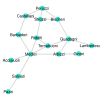

In [55]:
gplot(g1, nodelabel=df1.family)

## Measuring Homophily

- Our discussion of homophily so far has been conceptual... let's make it precise
- We'll compare observed edge frequencies with a random-formation benchmark
- This resembles a null-hypothesis comparison from statistics, but we won't carry out a formal significance test here

### Random Homophily

- Start with a thought experiment: edge formation does not depend on characteristic $X$
- We have $N$ nodes, and $N_x$ of them have characteristic $X$
  - The share with this characteristic is $p_x = N_x/N$
- For a simple benchmark, imagine drawing each endpoint's type independently from these population shares
  - Both have $X$: $p_x^2$
  - Neither has $X$: $(1-p_x)^2$
  - One has $X$ and the other does not:

$$\begin{aligned}
\Pr(\text{cross-characteristic pair}) &= p_x(1-p_x) + (1-p_x)p_x \\
&= 2p_x(1-p_x)
\end{aligned}$$

- This is our independent-endpoint benchmark. For a finite graph whose edges join distinct nodes, it is an approximation.
- **Question**: Why do we add two terms for a cross-characteristic pair?
- [this figure](#fig-homophily-endpoints) shows the four outcomes. What happens to the cross-type probability when one group gets smaller?

<span id="fig-homophily-endpoints"></span>



The two highlighted outcomes describe opposite orders of drawing the endpoint types. Together they give $2p_x(1-p_x)$; they do not mean we count an undirected edge twice.

### Counting Frequencies

- Now an empirical value...
- Let there be $e$ edges
- Let...

| variable | meaning |
|----------|---------|
| $e_{xx}$ | # edges between 2 $X$ |
| $e_{yy}$ | # edges between 2 not $X$ |
| $e_{xy}$ | # edges between 1 $X$  and 1 not $X$|




- Then $e = e_{xx} + e_{yy} + e_{xy}$
- We'll use these 4 numbers to count frequencies of edges between $X$ types and non-$X$ types

### Testing for Homophily

- We are now ready to compare our network with the benchmark
- Recall the two quantities:
  - $2p_x(1-p_x)$: the cross-type probability under the independent-endpoint benchmark
  - $e_{xy}/e$: the observed proportion of cross-characteristic edges
- The direction of the difference helps us describe the pattern:

| Comparison | Pattern |
| ---------- | ------- |
| $e_{xy}/e$ well above $2p_x(1-p_x)$ | consistent with inverse homophily |
| $e_{xy}/e$ near $2p_x(1-p_x)$ | near the random-formation benchmark |
| $e_{xy}/e$ well below $2p_x(1-p_x)$ | consistent with homophily |

- Intuition: fewer cross-type edges than the benchmark means more same-type edges
- A difference alone does not tell us whether it is statistically significant or whether the characteristic caused the edges to form

### Example: high school relationships

- Recall the graph of romantic relationships between high school students in [this figure](#fig-homophily-school-relationships).
- Each node is a student; an edge records a romantic relationship during the study's 18-month observation period.
- **Question**: does this graph exhibit homophily in gender? Why?

<span id="fig-homophily-school-relationships"></span>

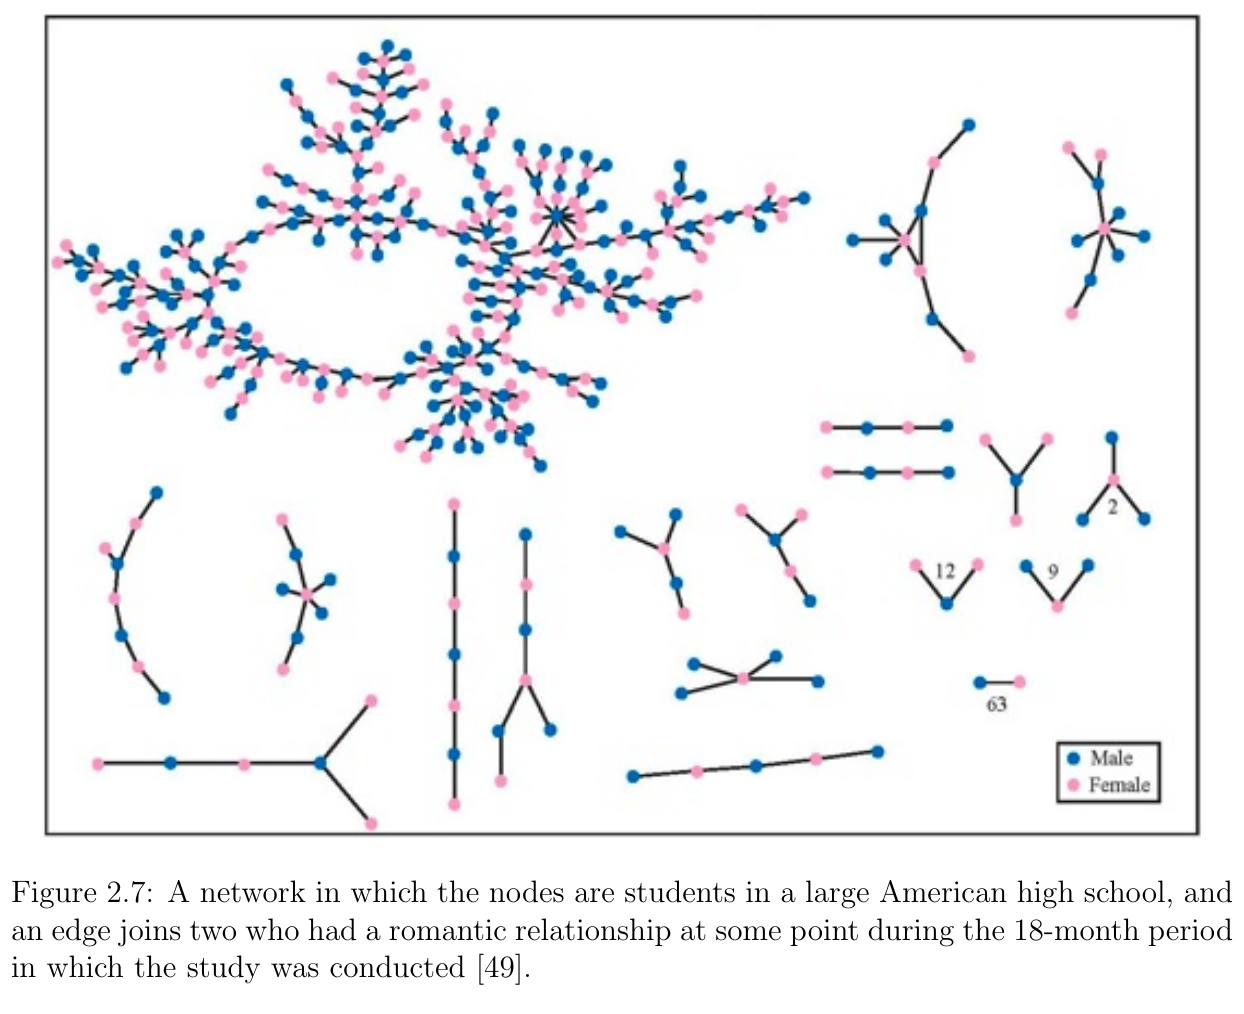

Romantic relationships in a high school. Original image reproduced from Easley and Kleinberg, *Networks, Crowds, and Markets* (2010), [Figure 2.7](https://www.cs.cornell.edu/home/kleinber/networks-book/networks-book-ch02.pdf). Study: Bearman, Moody, and Stovel (2004), *Chains of Affection: The Structure of Adolescent Romantic and Sexual Networks*. Image credited to Mark Newman on the [book's website](https://www.cs.cornell.edu/home/kleinber/networks-book/).

## Example: Florentines

- Let's work through an example of measuring homophily using the Florentine data
- I'll repeat the data below

In [56]:
df1

Row,family,wealth,priorates,high_wealth,high_power
,String,Int64,Int64?,Bool,Bool?
1,Acciaiuoli,10,53,false,true
2,Albizzi,36,65,false,true
3,Barbadori,55,missing,true,false
4,Bischeri,44,12,false,false
5,Castellani,20,22,false,false
6,Ginori,32,missing,false,false
7,Guadagni,8,21,false,false
8,Lamberteschi,42,0,false,false
9,Medici,103,53,true,true


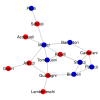

In [76]:
node_color = map(x -> x ? "blue" : "red", df1.high_wealth)
gplot(g1, nodelabel=df1.family, nodefillc=node_color)

### Step 1: Counting frequencies

- First we need to count frequencies for all our characteristics
- We'll do that here

In [58]:
using DataStructures

In [59]:
function count_frequencies(vals)
    counts = DataStructures.counter(vals)
    total = length(vals)
    Dict(c => v / total for (c, v) in pairs(counts))
end

count_frequencies (generic function with 1 method)

In [ ]:
count_frequencies(df1.high_wealth)

In [ ]:
Dict(
    n => count_frequencies(df1[!, n])
    for n in names(df1)[4:end]
)

Dict{String, Dict{Bool, Float64}} with 2 entries:
  "high_wealth" => Dict(0=>0.533333, 1=>0.466667)
  "high_power"  => Dict(0=>0.666667, 1=>0.333333)

### Step 2: Counting Edges

- Next we need to count the number of edges of each type
- This step is a bit trickier: we'll need both the graph and the DataFrame
- To not spoil the fun, we'll leave this code as an exercise on the homework
- For now we'll count by hand
- **Question**: Before looking at the tally, can you find every edge joining a high-wealth family to a low-wealth family?
- Use the H/L labels and dashed cross-type edges in [this figure](#fig-homophily-florentine-counts). Count each marriage once.

<span id="fig-homophily-florentine-counts"></span>



The wealth groups use the same threshold as our Julia code: high means strictly above the median of 42. Cross-type marriages account for 12 of the 20 edges.

- Let's compare the marriage network with the benchmark for `high_wealth`
- There are 7 high-wealth families among the 15 families in our graph
- Counting edge types gives:
  - High–high edges: 5
  - Low–low edges: 3
  - Cross edges: 12
- Total: $5 + 3 + 12 = 20$ edges
- The observed cross-edge proportion is $12/20 = 0.60$
- The high-wealth share is $p_x = 7/15 \approx 0.467$

In [ ]:
E = ne(g1)
Exy = 12  # cross edges
n_high = 7
N = nv(g1)
px = n_high / N

# compare with the benchmark
2 * px * (1-px), Exy/E

- Our independent-endpoint benchmark is $2(7/15)(8/15) \approx 0.498$
- The observed cross-edge share is $0.60$, about 0.10 higher
- This points in the direction of *inverse homophily*: more cross-wealth marriages than the benchmark predicts
- We haven't established statistical significance, and the comparison alone doesn't tell us why these families married

### Exercise

- Repeat the counting exercise, but for the high_power characteristic
- What do you find? Do you see homophily in this characteristic?